# End-to-End Project: US State Crime Segmentation (Clustering)

## 1) Problem statement (project-style)

**Stakeholder**: A public-policy research team.

**Goal**: Group U.S. states into *actionable segments* based on crime and social-condition indicators so that:

- interventions can be prioritized (e.g., social programs vs. law-enforcement resourcing),
- peer-state comparisons become meaningful ("compare me with states like me"),
- policy teams can design different playbooks for different state profiles.

**Why unsupervised?**

There is no ground-truth label such as "high-risk" or "low-risk" provided in this dataset. So we cannot train a classifier.
Instead, we use **clustering** to discover structure.

**Deliverables**

1. A final clustering model + chosen number of clusters.
2. Cluster profiles (what defines each segment) and member states.
3. A metric scorecard showing how choices (scaling, outlier handling, features, algorithm) change cluster quality.

---

## 2) What metric are we targeting?

Clustering has **no single perfect metric**. We will use a mix of internal validation metrics and interpretability.

### Primary metric (optimize)
- **Silhouette score** (range: -1 to +1, higher is better)
  - measures how well-separated clusters are
  - works nicely for comparing different `k` and algorithms

### Secondary metrics (sanity-check)
- **Davies–Bouldin index** (lower is better)
- **Calinski–Harabasz score** (higher is better)

### Important note
> **Common mistake**: Treating inertia (SSE) as the main metric.
>
> Inertia always decreases when `k` increases, and it is *scale-dependent*.
> Use inertia only for elbow intuition, not as the final "winner".


### Metric intuition (secondary metrics) — quick examples

We will optimize **silhouette**, but we sanity-check with DB and CH.

**Davies–Bouldin (DB) — lower is better**
- Think of it as: *"How much do clusters overlap?"*
- It compares **within-cluster scatter** vs **between-cluster separation**.
- If clusters are tight and far apart → DB goes down.

**Calinski–Harabasz (CH) — higher is better**
- Think of it as: *"How much between-cluster separation do we get per cluster?"*
- It’s like an ANOVA-style ratio: between-cluster dispersion / within-cluster dispersion.
- If clusters are compact and well separated → CH goes up.

> **Common mistake**: Picking the model with the best CH without checking silhouette.
> CH can sometimes favor solutions that split data into many small clusters.


In [88]:
# Imports + configuration

import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



def audit_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    # Quick EDA audit table: types, missingness, uniqueness.

    return (
        pd.DataFrame(
            {
                "dtype": df.dtypes.astype(str),
                "n_missing": df.isna().sum(),
                "missing_%": (df.isna().mean() * 100).round(2),
                "n_unique": df.nunique(dropna=False),
            }
        )
        .sort_values(["missing_%", "n_unique"], ascending=[False, True])
    )


def clip_quantiles(df: pd.DataFrame, cols: list[str], q_low: float = 0.01, q_high: float = 0.99) -> pd.DataFrame:
    # Winsorize/clip numeric columns to reduce extreme outlier influence on distances.

    out = df.copy()
    for c in cols:
        lo, hi = out[c].quantile([q_low, q_high])
        out[c] = out[c].clip(lo, hi)
    return out


def evaluate_clustering(X: np.ndarray, labels: np.ndarray) -> dict:
    # Compute a consistent metric bundle for clustering comparison.
    #
    # Why these metrics?
    # ------------------
    # 1) Silhouette (higher is better)
    #    - For each point i:
    #        a(i) = average distance from i to points in its own cluster
    #        b(i) = lowest average distance from i to points in any other cluster
    #      silhouette(i) = (b(i) - a(i)) / max(a(i), b(i))
    #    - Intuition: points should be close to their own cluster and far from others.
    #
    # 2) Davies–Bouldin index (lower is better)
    #    - For each cluster, compute how "wide" it is (scatter).
    #    - Compare that to distance between cluster centers.
    #    - Intuition: overlap/ambiguity between clusters should be low.
    #
    # 3) Calinski–Harabasz score (higher is better)
    #    - Ratio: (between-cluster dispersion) / (within-cluster dispersion)
    #    - Intuition: clusters should be far apart and internally tight.
    #
    # Important: these are *internal* metrics (no ground truth). Use them as guides,
    # then validate with interpretability.

    # If all labels are same, silhouette/CH are undefined
    n_clusters = len(np.unique(labels))
    if n_clusters < 2:
        return {
            "n_clusters": n_clusters,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }

    return {
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
    }


## 3) Load data

We’ll load the dataset and do a first pass on data quality.

> **Note to remember**: In clustering, even *small* data issues matter a lot because distance computations amplify them.


In [89]:
raw = pd.read_csv("state_crime.csv")

# Small cleanup driven by EDA:
# Some state names have trailing spaces (e.g., 'Kansas '), which can cause messy reporting.
raw["state"] = raw["state"].astype(str).str.strip()

display(raw.head())
print("Dataset shape:", raw.shape)


,state,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
0,Alabama,459.9,7.1,82.1,17.5,29.0,70.0,48.65,17.9,46.5,8.51375,56.777778
1,Alaska,632.6,3.2,91.4,9.0,25.5,68.3,44.46,8.6,34.5,4.00140,150.619048
2,Arizona,423.2,5.5,84.2,16.5,25.7,80.0,80.07,15.8,42.2,13.21155,65.107692
3,Arkansas,530.3,6.3,82.4,18.8,26.3,78.4,39.54,17.6,45.1,7.43352,72.643836
4,California,473.4,5.4,80.6,14.2,27.8,62.7,89.73,19.4,42.0,12.74166,73.968750


Dataset shape: (51, 12)


## 4) Data audit (quality checks)

We check:
- missing values
- duplicates
- basic ranges / suspicious values

> **Common mistake**: Skipping data audit because "it’s only 50 rows".
> In clustering, one outlier row can dominate the solution.


In [90]:
audit = audit_dataframe(raw)
display(audit)

print("Duplicate states:", raw["state"].duplicated().sum())


,dtype,n_missing,missing_%,n_unique
murder,float64,0,0.0,38
poverty,float64,0,0.0,40
single,float64,0,0.0,41
hs_grad,float64,0,0.0,42
graduation_gap,float64,0,0.0,42
social_stress_index,float64,0,0.0,46
white,float64,0,0.0,47
state,str,0,0.0,51
violent,float64,0,0.0,51
urban,float64,0,0.0,51


Duplicate states: 0


## 5) EDA (Univariate)

Univariate EDA answers:

1. **Scale**: which features have very different ranges? (scaling is required)
2. **Outliers**: are there extreme states that will dominate distances?
3. **Shape**: is a feature highly skewed? (RobustScaler or clipping may help)


,count,mean,std,min,25%,50%,75%,max
violent,51.0,411.482353,208.017447,119.900000,263.350000,366.400000,507.400000,1348.900000
murder,51.0,4.900000,3.646094,0.900000,2.650000,4.700000,6.150000,24.200000
hs_grad,51.0,86.878431,3.377769,79.900000,84.050000,87.400000,89.800000,91.800000
poverty,51.0,13.854902,3.110583,8.500000,11.500000,14.200000,16.400000,21.900000
single,51.0,25.186275,4.786565,17.900000,22.100000,25.500000,27.300000,48.000000
white,51.0,77.968627,13.553029,26.900000,70.600000,80.000000,87.750000,95.800000
urban,51.0,60.670196,20.802432,17.380000,46.565000,59.170000,78.415000,100.000000
graduation_gap,51.0,13.121569,3.377769,8.200000,10.200000,12.600000,15.950000,20.100000
social_stress_index,51.0,39.041176,6.875760,28.000000,34.500000,38.400000,42.400000,66.400000
urban_stress_index,51.0,8.282031,3.078181,1.981320,6.668860,8.513750,9.921030,18.400000


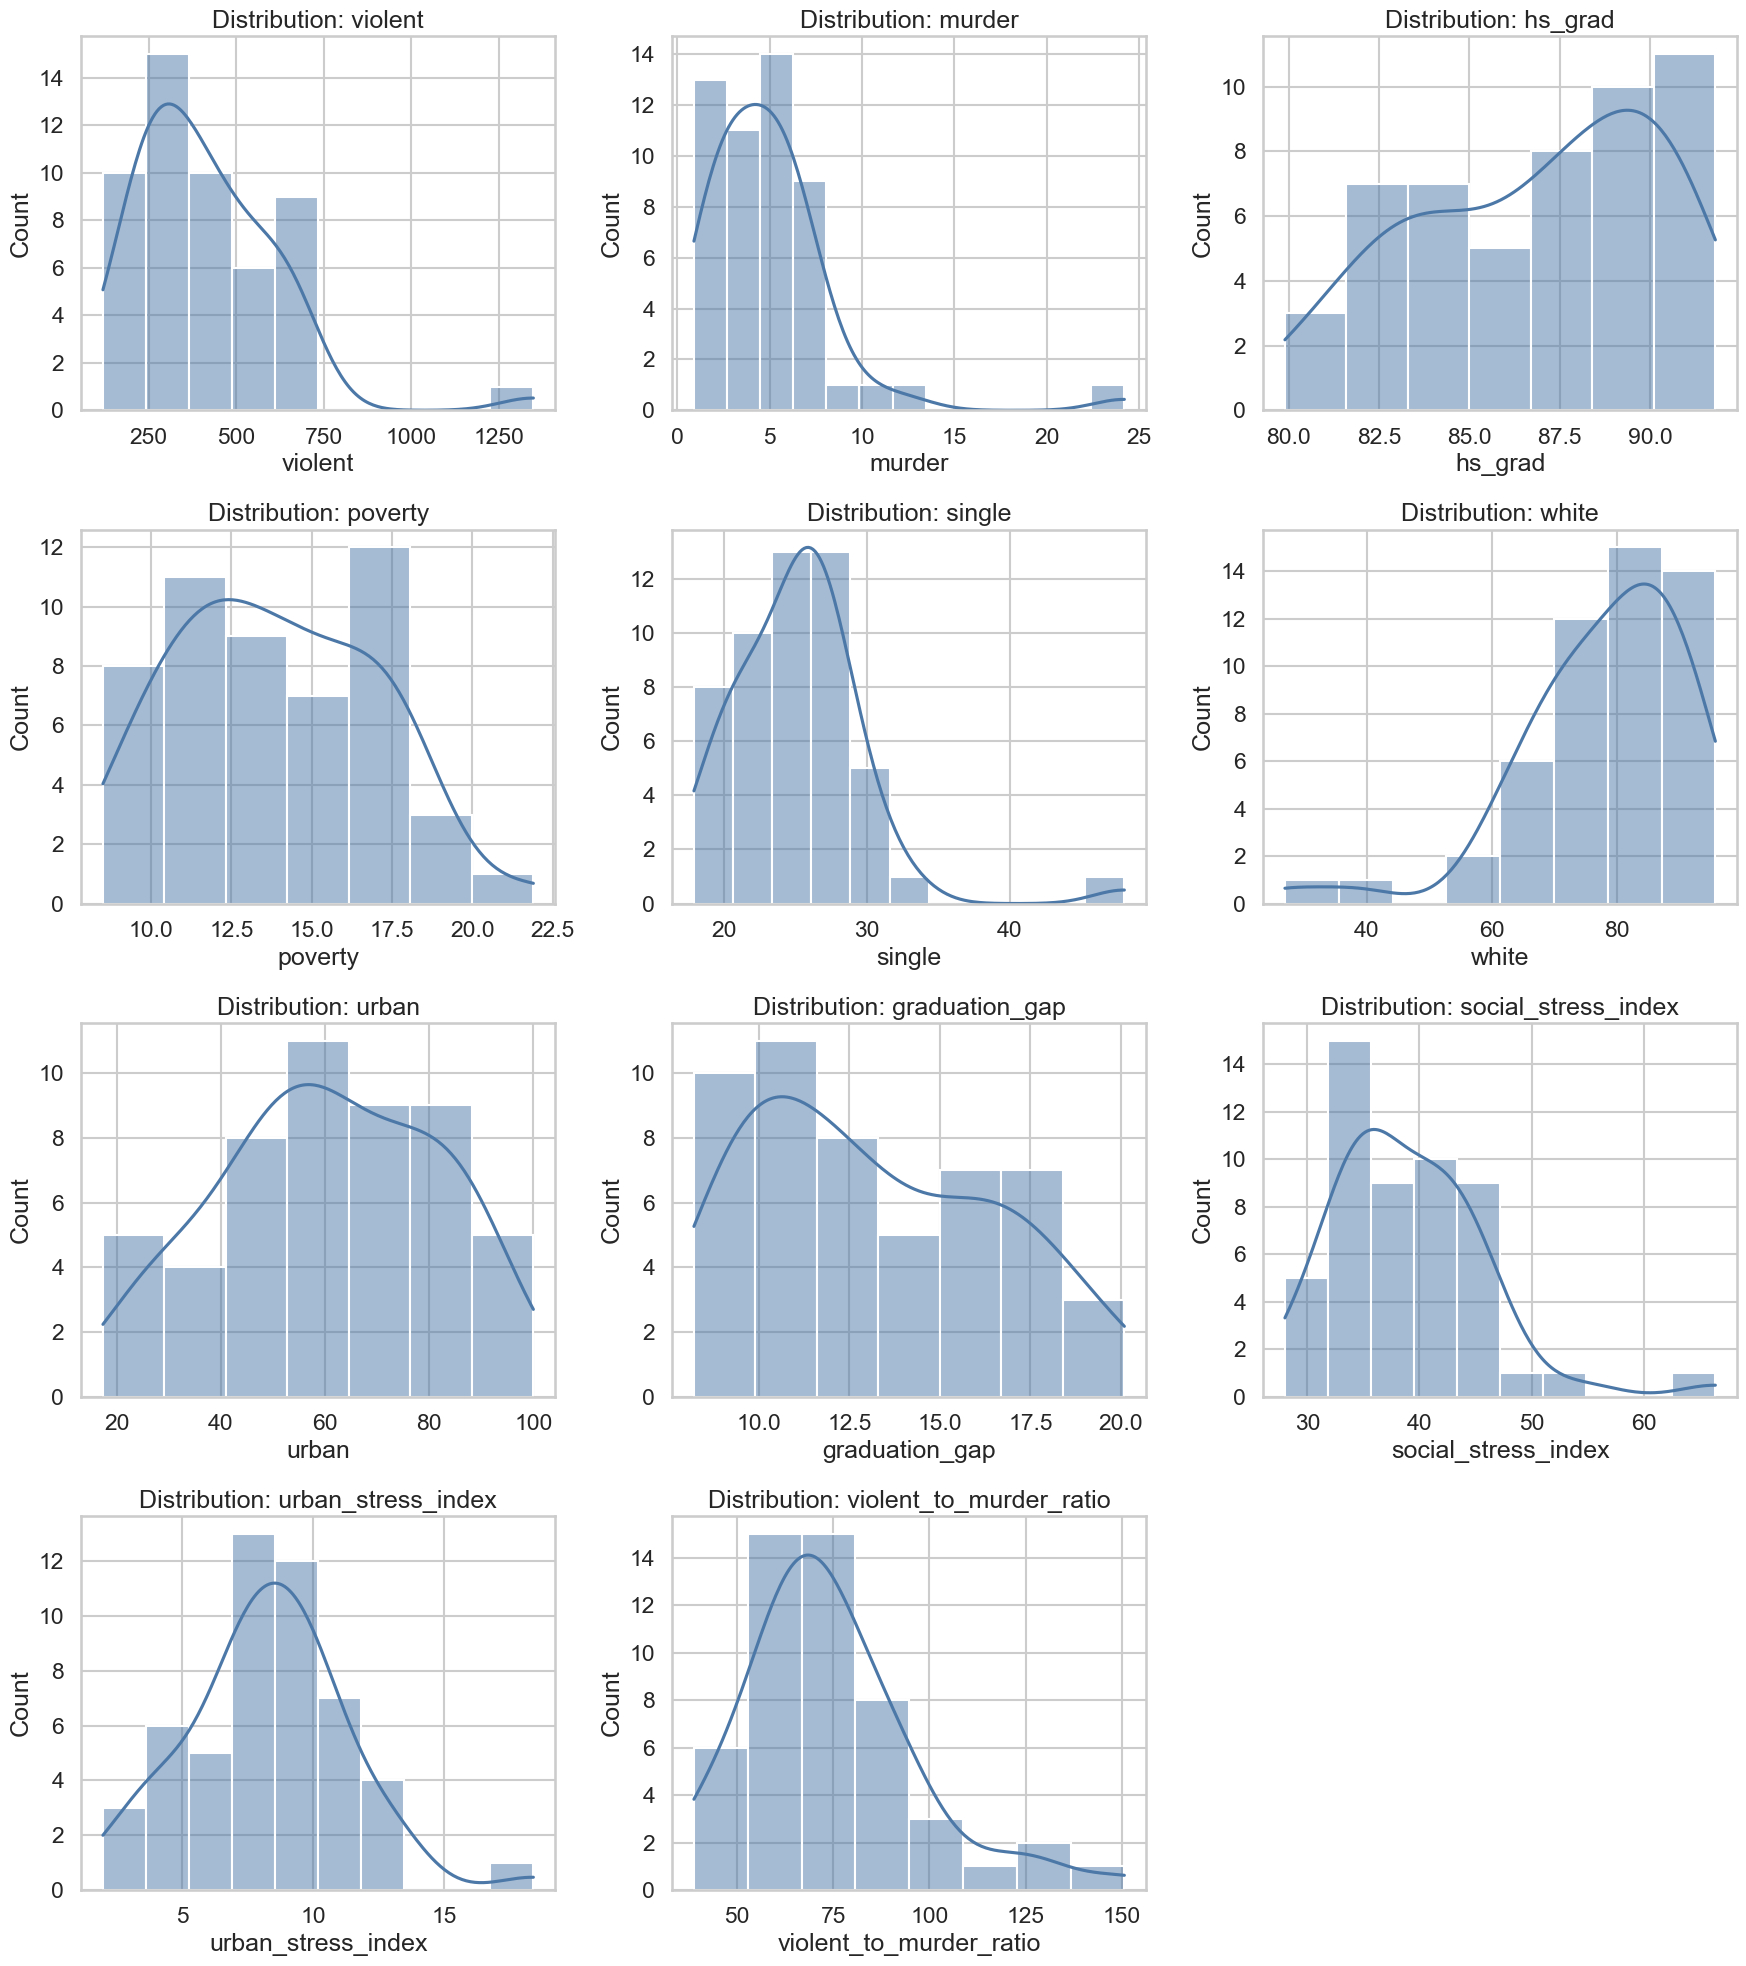

In [91]:
# Numeric columns (excluding the ID-like 'state')
num_cols = raw.columns.drop("state").tolist()

display(raw[num_cols].describe().T)

# Histograms
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    sns.histplot(raw[c], kde=True, ax=axes[i], color="#4C78A8")
    axes[i].set_title(f"Distribution: {c}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


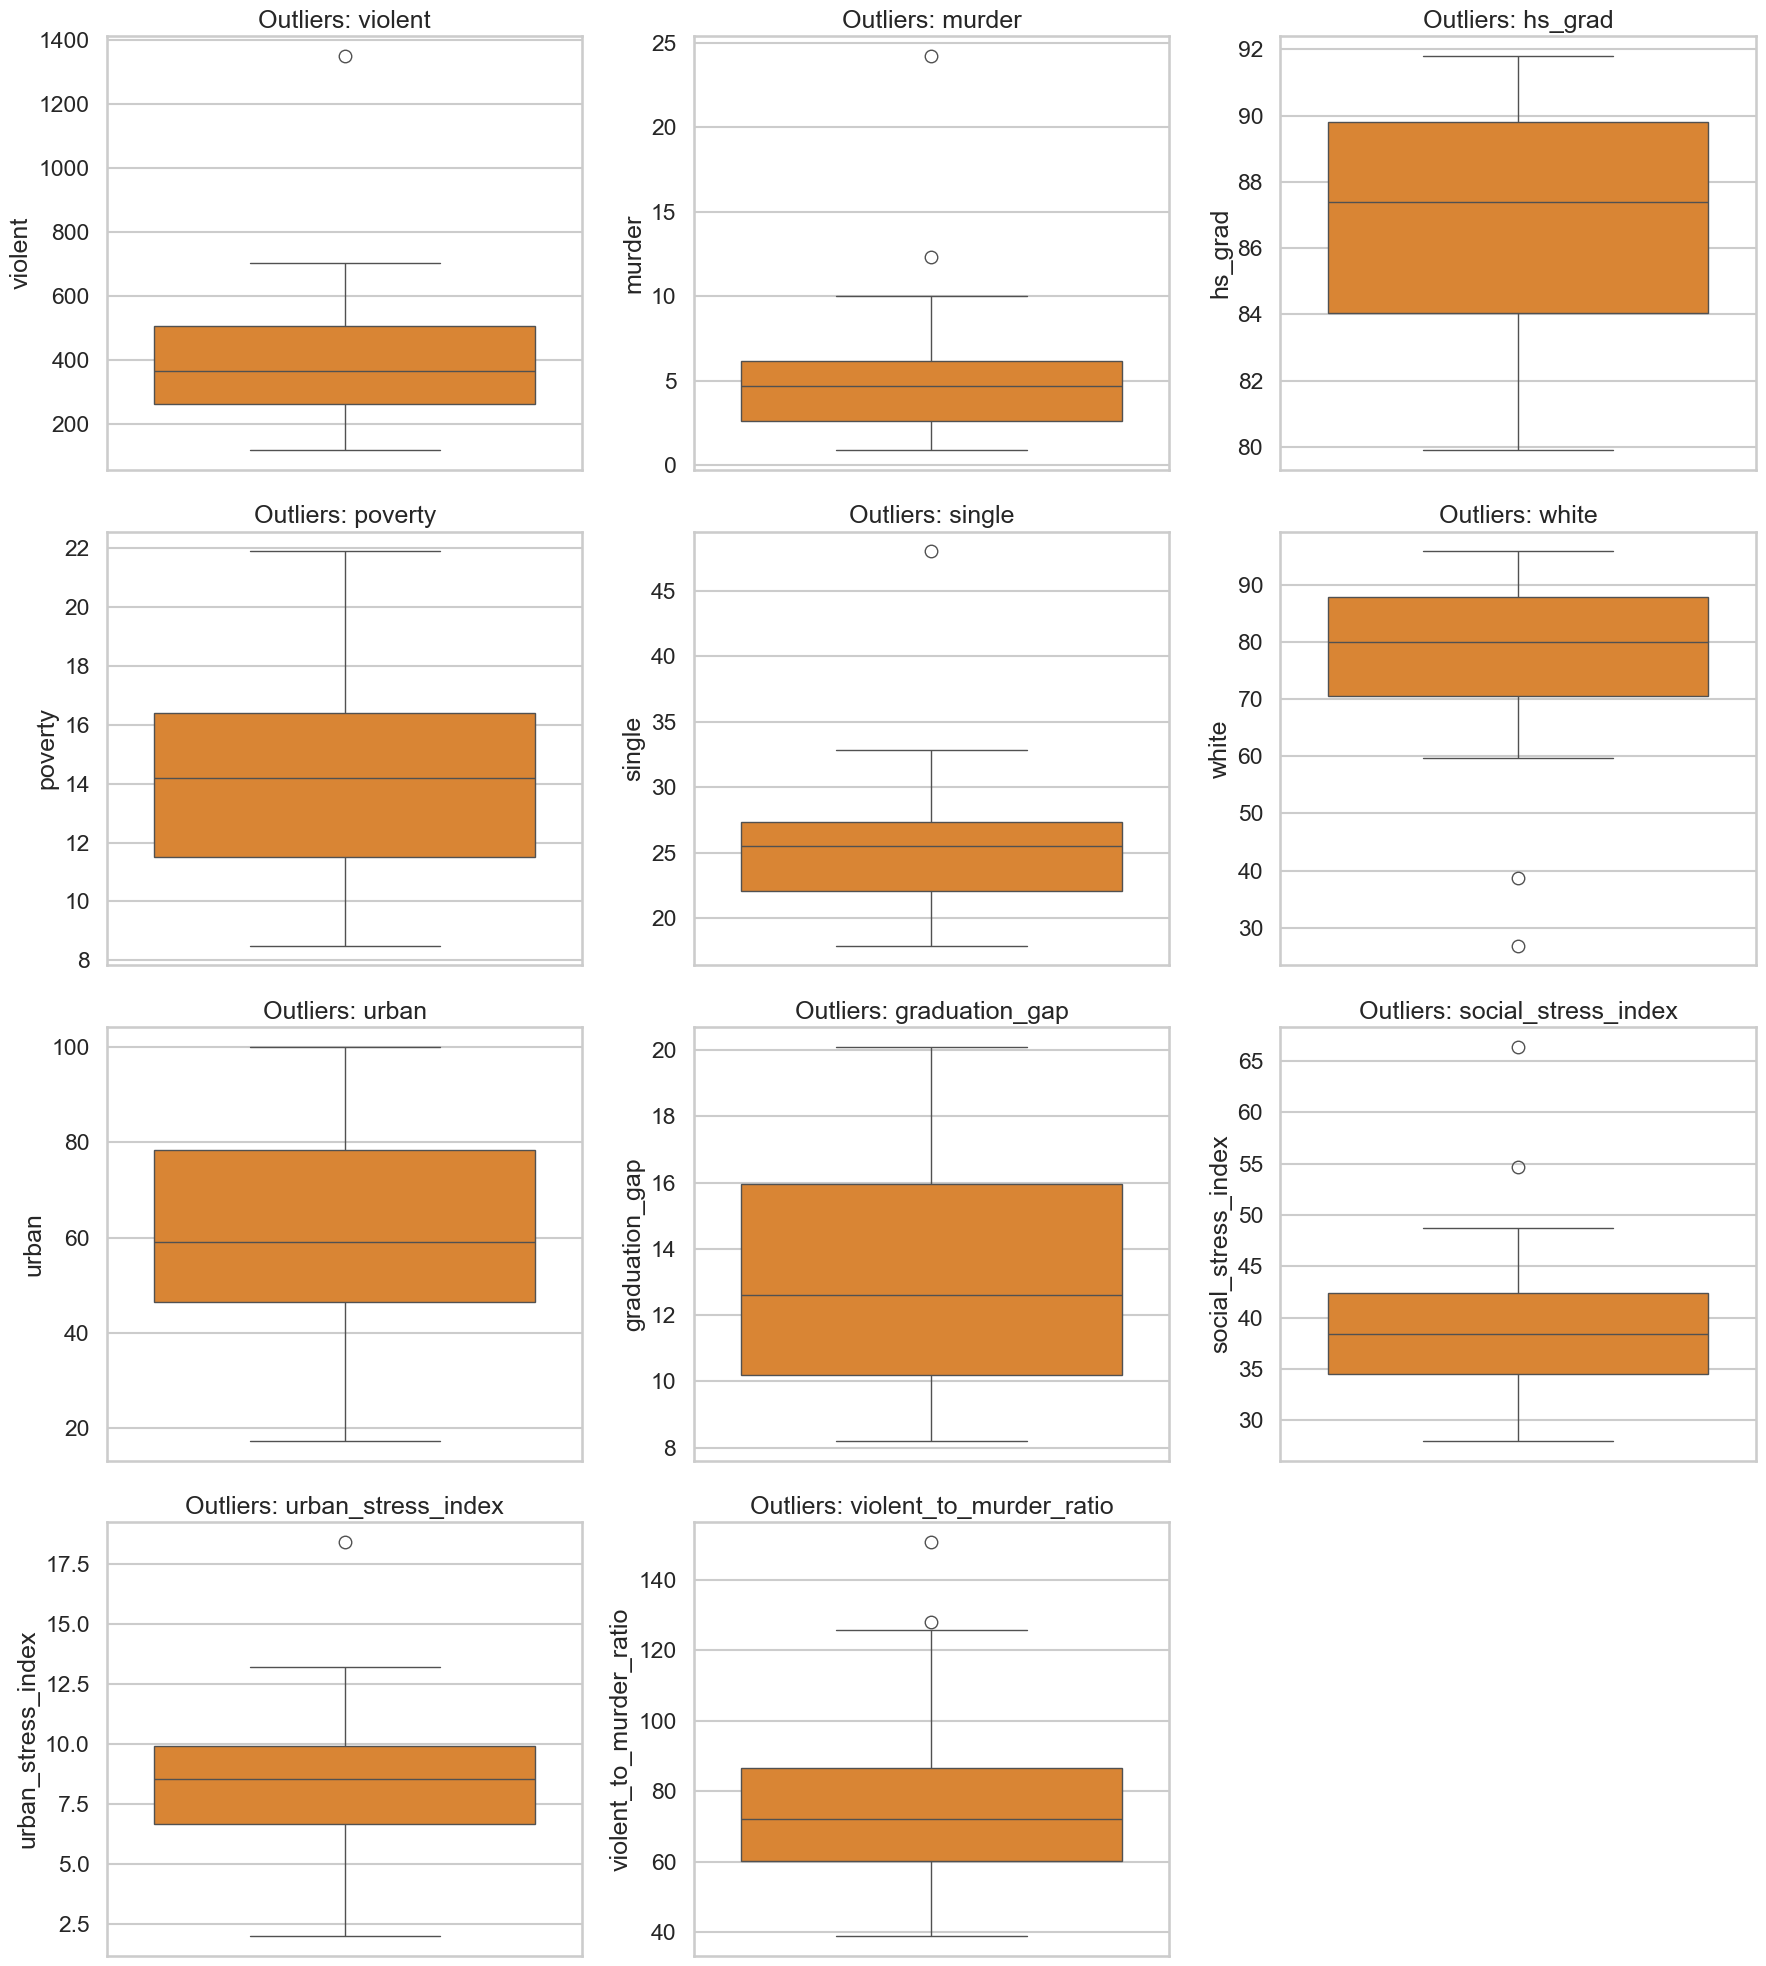

In [92]:
# Boxplots to visualize outliers
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    sns.boxplot(y=raw[c], ax=axes[i], color="#F58518")
    axes[i].set_title(f"Outliers: {c}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


### 🧑‍🏫 Note: Spotting Outliers with Boxplots
**What is this?** A boxplot shows the median (center line), the Interquartile Range or IQR (the box), and the "whiskers" (usually 1.5 * IQR). 


 Distance-based clustering (like K-Means) is *highly sensitive* to outliers. A single extreme value can pull a cluster centroid entirely out of place. We have to decide whether to exclude them, cap them, or use a robust algorithm.

### Univariate findings (data-driven) + modeling implications


We’ll compute:
- feature **ranges** and **standard deviations** (scale issues)
- **skewness** (heavy tails)
- **IQR outlier counts** (extreme values that can dominate Euclidean distance)



In [93]:
# 1) Scale + shape summary

scale_shape = (
    raw[num_cols]
    .agg(["min", "max", "mean", "std", "skew"])
    .T
)
scale_shape["range"] = scale_shape["max"] - scale_shape["min"]
scale_shape = scale_shape.sort_values("range", ascending=False)

display(scale_shape.round(3))

# 2) Outlier counts using a classic boxplot rule (1.5 * IQR)
out_rows = []
for c in num_cols:
    q1, q3 = raw[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    n_out = int(((raw[c] < lo) | (raw[c] > hi)).sum())
    out_rows.append({"feature": c, "n_outliers_(1.5IQR)": n_out, "lo": lo, "hi": hi})

outlier_summary = pd.DataFrame(out_rows).sort_values("n_outliers_(1.5IQR)", ascending=False)
display(outlier_summary)

# 3) Concrete examples: which states are at extremes for key features?
key_uni = ["violent", "murder", "poverty", "hs_grad", "violent_to_murder_ratio", "social_stress_index"]
for c in key_uni:
    display(
        raw[["state", c]]
        .sort_values(c, ascending=False)
        .head(5)
        .rename(columns={c: f"{c} (top 5)"})
    )


,min,max,mean,std,skew,range
violent,119.900,1348.900,411.482,208.017,1.905,1229.000
violent_to_murder_ratio,38.823,150.619,74.401,22.517,1.157,111.796
urban,17.380,100.000,60.670,20.802,-0.147,82.620
white,26.900,95.800,77.969,13.553,-1.521,68.900
social_stress_index,28.000,66.400,39.041,6.876,1.355,38.400
single,17.900,48.000,25.186,4.787,2.061,30.100
murder,0.900,24.200,4.900,3.646,3.166,23.300
urban_stress_index,1.981,18.400,8.282,3.078,0.413,16.419
poverty,8.500,21.900,13.855,3.111,0.259,13.400
hs_grad,79.900,91.800,86.878,3.378,-0.398,11.900


,feature,n_outliers_(1.5IQR),lo,hi
1,murder,2,-2.600000,11.400000
5,white,2,44.875000,113.475000
8,social_stress_index,2,22.650000,54.250000
10,violent_to_murder_ratio,2,20.836912,125.870424
0,violent,1,-102.725000,873.475000
4,single,1,14.300000,35.100000
9,urban_stress_index,1,1.790605,14.799285
2,hs_grad,0,75.425000,98.425000
3,poverty,0,4.150000,23.750000
6,urban,0,-1.210000,126.190000


,state,violent (top 5)
8,District of Columbia,1348.9
28,Nevada,704.6
40,South Carolina,675.1
42,Tennessee,666.0
31,New Mexico,652.8


,state,murder (top 5)
8,District of Columbia,24.2
18,Louisiana,12.3
31,New Mexico,10.0
13,Illinois,8.4
20,Maryland,7.7


,state,poverty (top 5)
24,Mississippi,21.9
3,Arkansas,18.8
17,Kentucky,18.6
8,District of Columbia,18.4
31,New Mexico,18.0


,state,hs_grad (top 5)
50,Wyoming,91.8
23,Minnesota,91.5
1,Alaska,91.4
29,New Hampshire,91.3
45,Vermont,91.0


,state,violent_to_murder_ratio (top 5)
1,Alaska,150.619048
15,Iowa,128.043478
21,Massachusetts,125.837838
7,Delaware,115.196429
28,Nevada,102.115942


,state,social_stress_index (top 5)
8,District of Columbia,66.4
24,Mississippi,54.7
18,Louisiana,48.7
31,New Mexico,47.1
0,Alabama,46.5


In [94]:
# 4) Convert univariate summaries into a compact findings table

top_range = scale_shape.head(3).index.tolist()
top_skew = scale_shape.sort_values("skew", key=lambda s: s.abs(), ascending=False).head(3).index.tolist()
top_outliers = outlier_summary.head(3)["feature"].tolist()

univariate_findings = pd.DataFrame(
    [
        {
            "finding": "Strong scale differences across features",
            "evidence": f"Largest ranges: {top_range}",
            "why_it_matters": "Distance-based clustering is dominated by large-scale features.",
            "preprocessing_action": "Use StandardScaler (or RobustScaler) before KMeans/Agglomerative.",
        },
        {
            "finding": "Some features are highly skewed / heavy-tailed",
            "evidence": f"Most skewed (|skew|): {top_skew}",
            "why_it_matters": "Heavy tails make cluster boundaries sensitive to extreme points.",
            "preprocessing_action": "Consider clipping/winsorization or RobustScaler; re-check metrics.",
        },
        {
            "finding": "Outliers exist in multiple features",
            "evidence": f"Most IQR-outliers: {top_outliers}",
            "why_it_matters": "A few states can pull centroids and distort distances.",
            "preprocessing_action": "Test a mild quantile clip (1%–99%) and compare scorecard.",
        },
    ]
)

display(univariate_findings)


,finding,evidence,why_it_matters,preprocessing_action
0,Strong scale differences across features,"Largest ranges: ['violent', 'violent_to_murder...",Distance-based clustering is dominated by larg...,Use StandardScaler (or RobustScaler) before KM...
1,Some features are highly skewed / heavy-tailed,"Most skewed (|skew|): ['murder', 'single', 'vi...",Heavy tails make cluster boundaries sensitive ...,Consider clipping/winsorization or RobustScale...
2,Outliers exist in multiple features,"Most IQR-outliers: ['murder', 'white', 'social...",A few states can pull centroids and distort di...,Test a mild quantile clip (1%–99%) and compare...


#### Interpretation note

Outliers are not always “bad data.” For policy segmentation, an outlier state might be the *most important* to handle.

So our process is:
1. **Detect** outliers using boxplots + IQR rule.
2. **Decide** whether to keep them as-is or dampen their influence.
3. **Validate** the decision with the clustering scorecard (silhouette/DB/CH) and cluster interpretability.


## 6) EDA (Bivariate)

Bivariate EDA helps decide:
- redundant features (strongly correlated)
- intuitive "stories" (e.g., poverty ↔ violent crime)
- whether feature engineering is helping

> **Common mistake**: Using all correlated features blindly. In clustering this can overweight one theme (e.g., “social stress”) because it is measured multiple times.


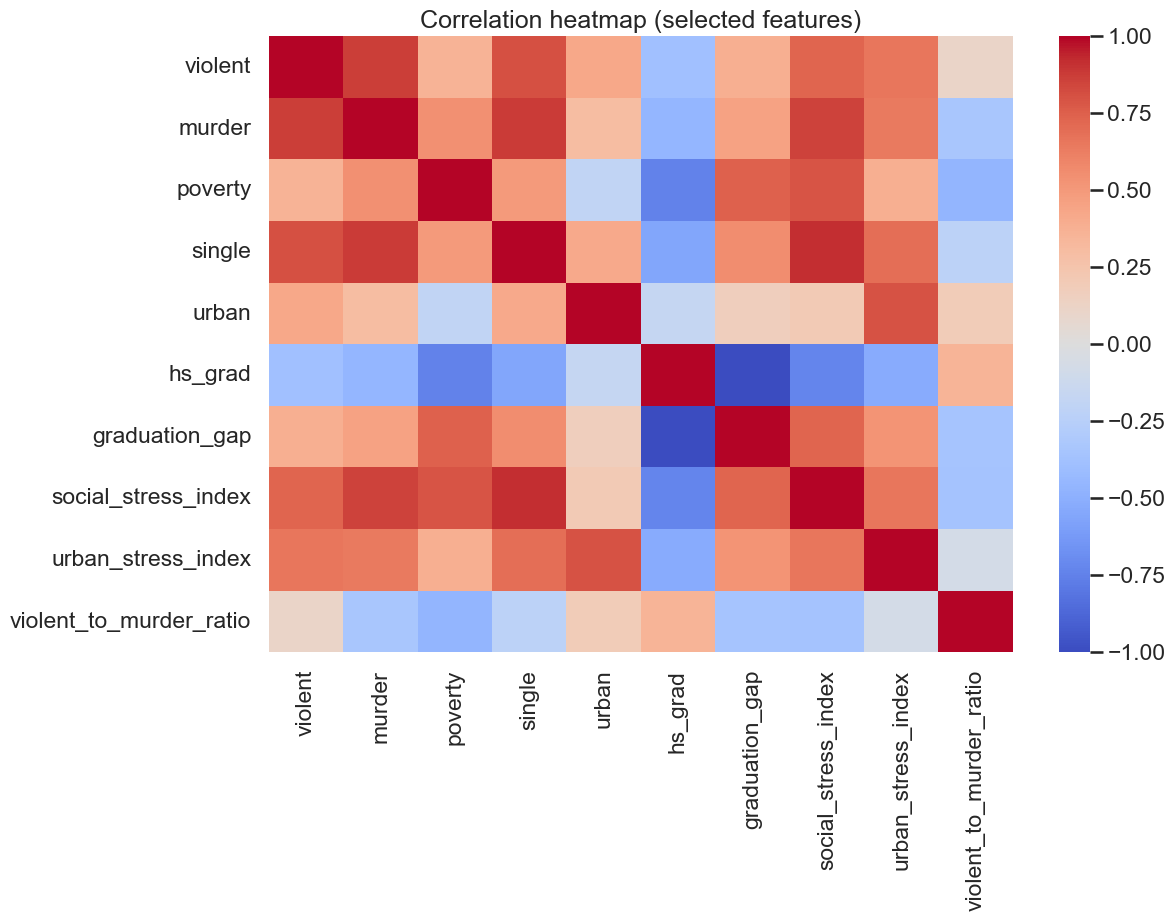

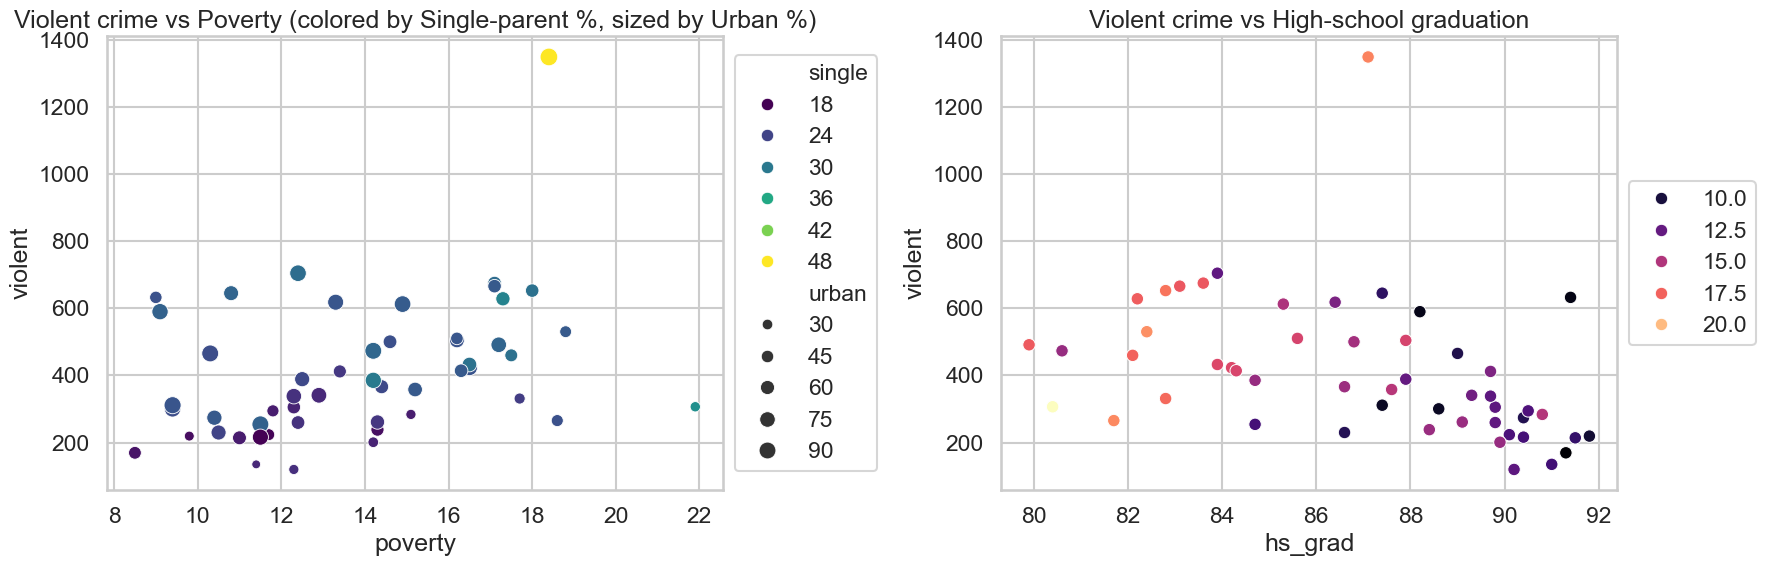

In [95]:
selected = [
    "violent",
    "murder",
    "poverty",
    "single",
    "urban",
    "hs_grad",
    "graduation_gap",
    "social_stress_index",
    "urban_stress_index",
    "violent_to_murder_ratio",
]

plt.figure(figsize=(12, 8))
sns.heatmap(raw[selected].corr(numeric_only=True), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap (selected features)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=raw, x="poverty", y="violent", hue="single", size="urban", palette="viridis", ax=axes[0])
axes[0].set_title("Violent crime vs Poverty (colored by Single-parent %, sized by Urban %)")
axes[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))

sns.scatterplot(data=raw, x="hs_grad", y="violent", hue="poverty", palette="magma", ax=axes[1])
axes[1].set_title("Violent crime vs High-school graduation")
axes[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


Red means strong positive correlation (near +1), blue means strong negative correlation (near -1).

 Multicollinearity! If two features are highly correlated (e.g., `poverty` and `single`), they represent the *same underlying information*. In clustering, feeding redundant features essentially gives them "double voting power" in the distance calculation. We might need to drop one or use PCA.

## 7) PCA for structure (visual diagnostic)

PCA is not the clustering model here.
We use PCA to:

- visualize high-dimensional structure in 2D,
- understand which features drive the main directions,
- debug whether scaling worked.

> **Common mistake**: PCA without scaling. PCA is variance-based and will be dominated by large-scale features.


Explained variance ratio (PC1, PC2): [0.564 0.192]


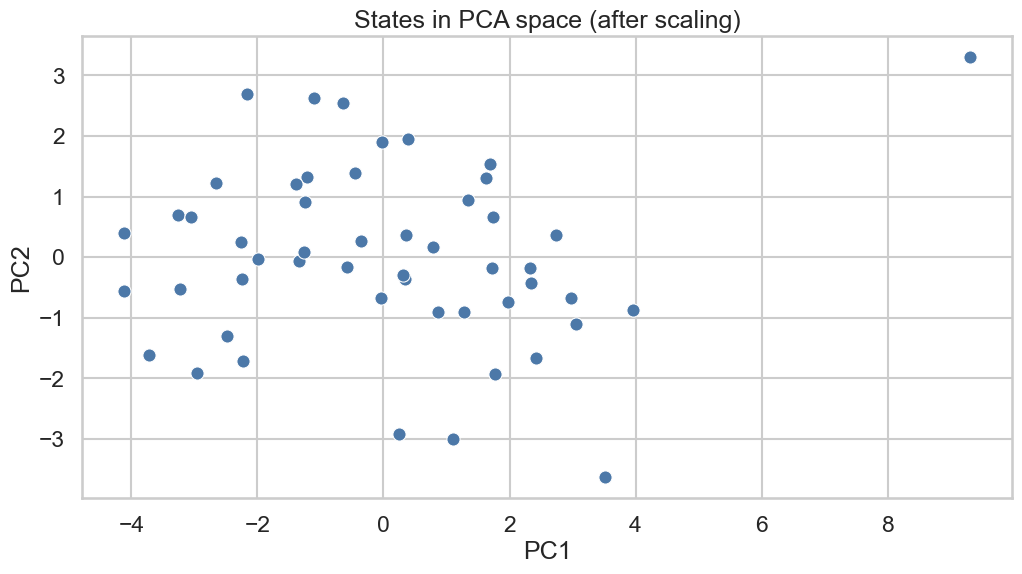

,PC1_loading,PC2_loading
social_stress_index,0.384563,-0.102184
single,0.370507,0.123580
murder,0.349682,0.067199
urban_stress_index,0.319675,0.248769
violent,0.316899,0.264435
graduation_gap,0.311930,-0.282792
hs_grad,-0.311930,0.282792
poverty,0.279917,-0.416037
white,-0.269614,-0.262808
urban,0.168803,0.495204


In [96]:
feature_cols = raw.columns.drop("state").tolist()
X = raw[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["state"] = raw["state"]

print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 3))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=90, color="#4C78A8")
plt.title("States in PCA space (after scaling)")
plt.show()

# PCA loadings: rough "feature importance" for each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1_loading", "PC2_loading"],
).sort_values("PC1_loading", key=lambda s: s.abs(), ascending=False)

display(loadings.head(10))


### Visualizing Clusters with PCA
We have 11 features, meaning our data lives in 11-dimensional space. Our human eyes can only see in 2D or 3D. 

**Why PCA?** Principal Component Analysis (PCA) mathematically squishes those 11 dimensions down into 2 dimensions (PC1 and PC2) while trying to preserve as much variance/distance information as possible. This allows us to plot the points on a flat screen and see if our K-Means algorithm actually separated the states into distinct groups!

## 8) EDA → Preprocessing  

From EDA we learned:

1. Features are on very different **scales** → we must scale.
2. Some features show **outliers / heavy tails** → consider robust scaling or clipping.
3. Some features are **strongly correlated** → not necessarily remove them, but be aware it can overweight a theme.

We will therefore test multiple preprocessing variants and show how metrics change.


## 9) Modeling plan (iterations + tuning)

We will build a *metric scorecard* across these iterations:

### Iteration A — Bad baseline 
- KMeans on raw (unscaled) features

### Iteration B — Proper baseline
- StandardScaler + KMeans, tune `k`

### Iteration C — Outlier-aware distance
- Quantile clipping + StandardScaler + KMeans

### Iteration D — Alternative algorithms
- Agglomerative clustering 

We’ll keep the **same evaluation metrics** so comparisons are fair.


In [97]:
def run_kmeans_grid(X_in: np.ndarray, k_values: list[int], n_init: int = 50) -> pd.DataFrame:
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=n_init)
        labels = model.fit_predict(X_in)
        metrics = evaluate_clustering(X_in, labels)
        rows.append(
            {
                "algo": "KMeans",
                "k": k,
                "params": f"n_init={n_init}",
                "inertia": model.inertia_,
                **metrics,
            }
        )
    return pd.DataFrame(rows)


def run_agglomerative_grid(X_in: np.ndarray, k_values: list[int], linkages: list[str]) -> pd.DataFrame:
    rows = []
    for linkage in linkages:
        for k in k_values:
            # sklearn API changed across versions: `metric` vs `affinity`.
            try:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric="euclidean")
            except TypeError:
                model = AgglomerativeClustering(n_clusters=k, linkage=linkage, affinity="euclidean")

            labels = model.fit_predict(X_in)
            metrics = evaluate_clustering(X_in, labels)
            rows.append(
                {
                    "algo": "Agglomerative",
                    "k": k,
                    "params": f"linkage={linkage}",
                    "inertia": np.nan,
                    **metrics,
                }
            )
    return pd.DataFrame(rows)




## 10) Iteration A — Bad baseline (unscaled)

We intentionally do this *once* to demonstrate why scaling is mandatory.


,algo,k,params,inertia,n_clusters,silhouette,davies_bouldin,calinski_harabasz
1,KMeans,3,n_init=50,377373.573940,3,0.566600,0.414619,117.568370
0,KMeans,2,n_init=50,950118.078360,2,0.563274,0.600877,65.800815
2,KMeans,4,n_init=50,188108.600184,4,0.526369,0.440220,169.726800
3,KMeans,5,n_init=50,121657.504189,5,0.445338,0.574897,198.919222
4,KMeans,6,n_init=50,93250.497427,6,0.407933,0.619735,205.841327
5,KMeans,7,n_init=50,76171.521684,7,0.403382,0.671467,206.973130
6,KMeans,8,n_init=50,67077.770143,8,0.347270,0.772413,197.710690


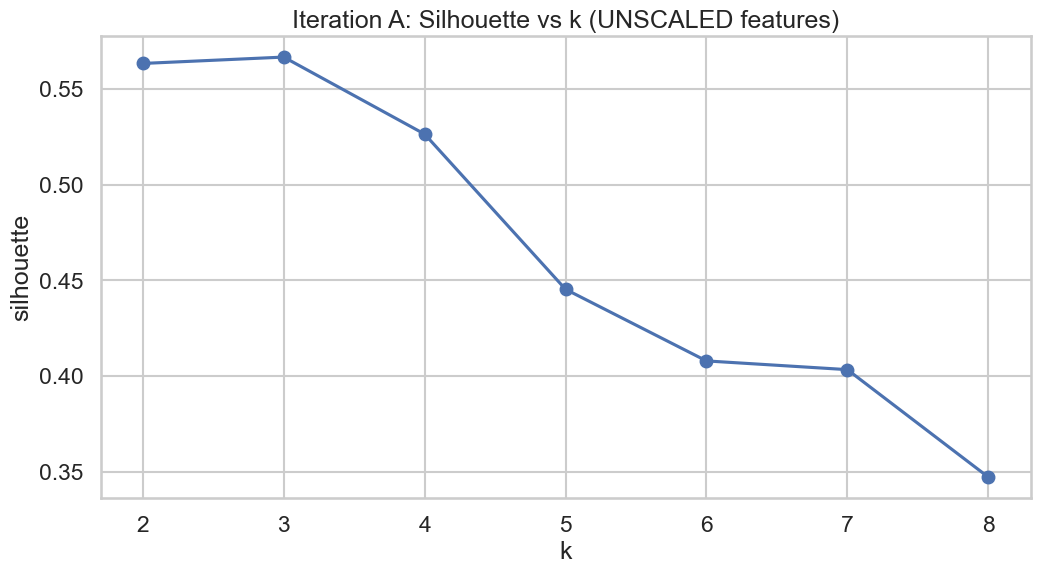

In [98]:
k_values = list(range(2, 9))

X_raw = raw[feature_cols].to_numpy(dtype=float)

baseline_raw = run_kmeans_grid(X_raw, k_values=k_values, n_init=50)
display(baseline_raw.sort_values(["silhouette"], ascending=False).head(10))

plt.plot(baseline_raw["k"], baseline_raw["silhouette"], marker="o")
plt.title("Iteration A: Silhouette vs k (UNSCALED features)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.show()


## 11) Iteration B — Proper baseline (StandardScaler + KMeans)

Now we do it correctly.


,algo,k,params,inertia,n_clusters,silhouette,davies_bouldin,calinski_harabasz
1,KMeans,3,n_init=100,262.290402,3,0.330981,0.816642,27.332416
0,KMeans,2,n_init=100,352.918882,2,0.326738,1.138397,28.890420
2,KMeans,4,n_init=100,205.856748,4,0.258577,0.966729,27.028072
3,KMeans,5,n_init=100,176.615591,5,0.254670,1.008324,25.028485
6,KMeans,8,n_init=100,120.150544,8,0.235072,0.910372,22.539018
4,KMeans,6,n_init=100,152.473752,6,0.228959,1.057360,24.113896
5,KMeans,7,n_init=100,132.549571,7,0.226829,1.021433,23.704112


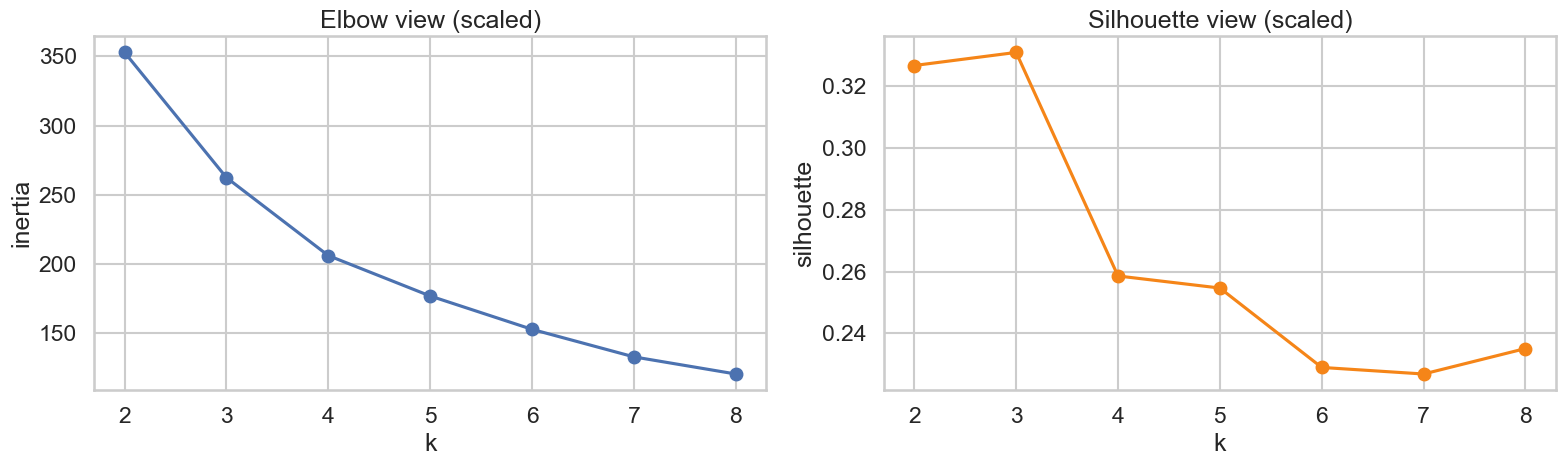

Best k by silhouette (Iteration B): 3


In [99]:
X_std = StandardScaler().fit_transform(X_raw)

baseline_std = run_kmeans_grid(X_std, k_values=k_values, n_init=100)
display(baseline_std.sort_values(["silhouette"], ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(baseline_std["k"], baseline_std["inertia"], marker="o")
axes[0].set_title("Elbow view (scaled)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")

axes[1].plot(baseline_std["k"], baseline_std["silhouette"], marker="o", color="#F58518")
axes[1].set_title("Silhouette view (scaled)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()

best_k_std = int(baseline_std.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Best k by silhouette (Iteration B):", best_k_std)


## 12) Iteration C — Outlier-aware preprocessing (clipping + scaling)

Because outliers can dominate Euclidean distances, we test a mild winsorization (1st–99th percentiles).

> **Note**: This is not always required, but it’s a useful option when you see extreme points in univariate EDA.


,algo,k,params,inertia,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,2,n_init=200,338.023242,2,0.332725,1.115697,32.322810
2,KMeans,4,n_init=200,221.441130,4,0.254786,1.004380,24.023340
1,KMeans,3,n_init=200,277.085305,3,0.245060,1.306925,24.591534
3,KMeans,5,n_init=200,190.558674,5,0.234467,1.193698,22.355714
4,KMeans,6,n_init=200,164.202066,6,0.224690,1.117453,21.748700
5,KMeans,7,n_init=200,143.368073,7,0.223937,1.034920,21.362037
6,KMeans,8,n_init=200,129.023095,8,0.221915,1.072812,20.566647


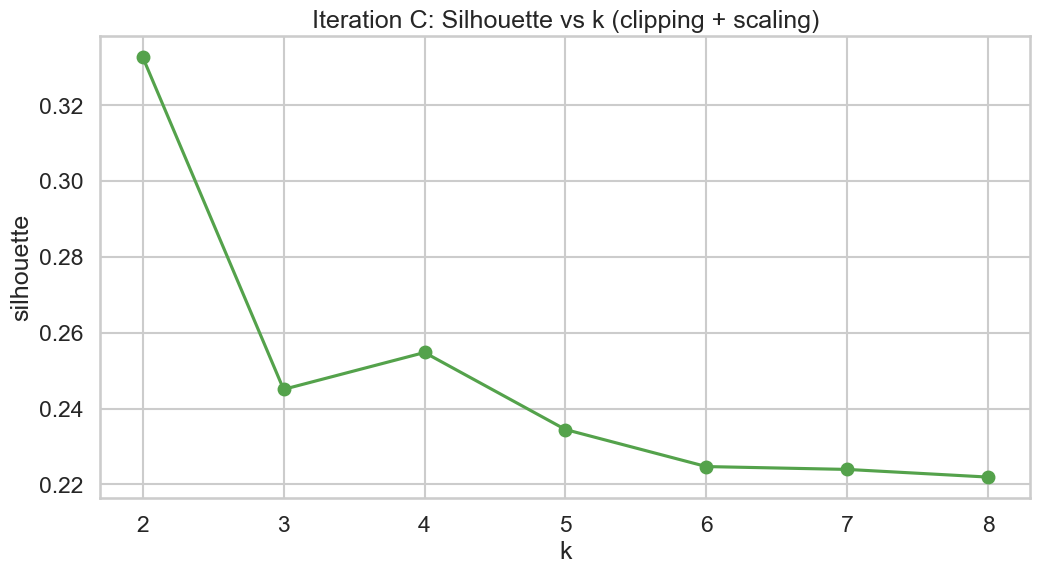

In [100]:
raw_clipped = clip_quantiles(raw, cols=feature_cols, q_low=0.01, q_high=0.99)
X_clip = raw_clipped[feature_cols].to_numpy(dtype=float)
X_clip_std = StandardScaler().fit_transform(X_clip)

clip_std = run_kmeans_grid(X_clip_std, k_values=k_values, n_init=200)
display(clip_std.sort_values(["silhouette"], ascending=False).head(10))

plt.plot(clip_std["k"], clip_std["silhouette"], marker="o", color="#54A24B")
plt.title("Iteration C: Silhouette vs k (clipping + scaling)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.show()


## 13) Iteration D — Alternative algorithms + tuning

We compare:
- **Agglomerative clustering**: can capture non-spherical clusters

> **Common mistake**: Trying 10 algorithms without a scorecard. Always log metrics in a consistent table.


In [101]:
agg = run_agglomerative_grid(X_std, k_values=k_values, linkages=["ward", "complete", "average"])

display(agg.sort_values("silhouette", ascending=False).head(10))


,algo,k,params,inertia,n_clusters,silhouette,davies_bouldin,calinski_harabasz
7,Agglomerative,2,linkage=complete,NaN,2,0.627541,0.256305,12.940718
14,Agglomerative,2,linkage=average,NaN,2,0.627541,0.256305,12.940718
8,Agglomerative,3,linkage=complete,NaN,3,0.315010,0.852584,25.033892
0,Agglomerative,2,linkage=ward,NaN,2,0.312897,1.171721,26.956078
1,Agglomerative,3,linkage=ward,NaN,3,0.306128,0.842088,24.917963
16,Agglomerative,4,linkage=average,NaN,4,0.292665,0.722481,18.801609
15,Agglomerative,3,linkage=average,NaN,3,0.264818,0.479509,7.866373
10,Agglomerative,5,linkage=complete,NaN,5,0.258019,0.953131,20.135593
17,Agglomerative,5,linkage=average,NaN,5,0.252612,0.667507,15.475515
9,Agglomerative,4,linkage=complete,NaN,4,0.247776,0.924271,20.138969


## 14) Metric scorecard (how metrics improve)

This is where we explicitly show **progress** across iterations.

We track:
- silhouette (higher is better)
- Davies–Bouldin (lower is better)
- Calinski–Harabasz (higher is better)


In [102]:
def add_iteration_tag(df: pd.DataFrame, iteration: str, preprocessing: str) -> pd.DataFrame:
    out = df.copy()
    out.insert(0, "iteration", iteration)
    out.insert(1, "preprocessing", preprocessing)
    return out


scorecard = pd.concat(
    [
        add_iteration_tag(baseline_raw, "A", "raw/unscaled"),
        add_iteration_tag(baseline_std, "B", "StandardScaler"),
        add_iteration_tag(clip_std, "C", "clip(1%-99%)+StandardScaler"),
        add_iteration_tag(agg, "D", "StandardScaler"),
    ],
    ignore_index=True,
)

# A convenient single sort order:
scorecard_sorted = scorecard.sort_values(
    ["silhouette", "davies_bouldin"], ascending=[False, True]
)

display(scorecard_sorted.head(20).round(4))

best_row = scorecard_sorted.iloc[0]
print("Best configuration by (silhouette desc, DB asc):")
display(best_row)


,iteration,preprocessing,algo,k,params,inertia,n_clusters,silhouette,davies_bouldin,calinski_harabasz
28,D,StandardScaler,Agglomerative,2,linkage=complete,NaN,2,0.6275,0.2563,12.9407
35,D,StandardScaler,Agglomerative,2,linkage=average,NaN,2,0.6275,0.2563,12.9407
1,A,raw/unscaled,KMeans,3,n_init=50,377373.5739,3,0.5666,0.4146,117.5684
0,A,raw/unscaled,KMeans,2,n_init=50,950118.0784,2,0.5633,0.6009,65.8008
2,A,raw/unscaled,KMeans,4,n_init=50,188108.6002,4,0.5264,0.4402,169.7268
3,A,raw/unscaled,KMeans,5,n_init=50,121657.5042,5,0.4453,0.5749,198.9192
4,A,raw/unscaled,KMeans,6,n_init=50,93250.4974,6,0.4079,0.6197,205.8413
5,A,raw/unscaled,KMeans,7,n_init=50,76171.5217,7,0.4034,0.6715,206.9731
6,A,raw/unscaled,KMeans,8,n_init=50,67077.7701,8,0.3473,0.7724,197.7107
14,C,clip(1%-99%)+StandardScaler,KMeans,2,n_init=200,338.0232,2,0.3327,1.1157,32.3228


Best configuration by (silhouette desc, DB asc):


iteration                           D
preprocessing          StandardScaler
algo                    Agglomerative
k                                   2
params               linkage=complete
inertia                           NaN
n_clusters                          2
silhouette                   0.627541
davies_bouldin               0.256305
calinski_harabasz           12.940718
Name: 28, dtype: object

## 15) Choose a final model (metric + interpretability)

We’ll choose a model for demonstration.

**Default classroom choice**: `k=3` KMeans after scaling, because it is easy to explain and profile.

**But** if the best silhouette is achieved at another `k` or algorithm, we’ll highlight that tradeoff.


In [103]:
# You can change this choice after inspecting the scorecard.
FINAL_ALGO = "KMeans"
FINAL_K = 3
FINAL_PREPROCESSING = "StandardScaler"  # {"StandardScaler", "clip"}

if FINAL_PREPROCESSING == "StandardScaler":
    X_final = X_std
elif FINAL_PREPROCESSING == "clip":
    X_final = X_clip_std
else:
    raise ValueError("Unknown preprocessing")

if FINAL_ALGO == "KMeans":
    final_model = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=200)
    final_labels = final_model.fit_predict(X_final)
elif FINAL_ALGO == "Agglomerative":
    try:
        final_model = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward", metric="euclidean")
    except TypeError:
        final_model = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward", affinity="euclidean")
    final_labels = final_model.fit_predict(X_final)
    final_labels = final_model.fit_predict(X_final)
else:
    raise ValueError("Unknown algorithm")

final_metrics = evaluate_clustering(X_final, final_labels)
print("Final metrics:", {k: round(v, 4) if isinstance(v, float) else v for k, v in final_metrics.items()})

df_labeled = raw.copy()
df_labeled["cluster"] = final_labels
display(df_labeled[["state", "cluster"]].head())

print("Cluster sizes:\n", df_labeled["cluster"].value_counts().sort_index())


Final metrics: {'n_clusters': 3, 'silhouette': 0.331, 'davies_bouldin': 0.8166, 'calinski_harabasz': 27.3324}


,state,cluster
0,Alabama,0
1,Alaska,1
2,Arizona,0
3,Arkansas,0
4,California,0


Cluster sizes:
 cluster
0    24
1    26
2     1
Name: count, dtype: int64


## Conclusion: Which Model is Best and Why?

When deciding on the "best" model, we have to look at both the **mathematical metrics** and the **business interpretability**. Let's break down the scorecard results:

### 1. The Flaw of "Raw" Metrics
As we learned earlier, clustering on `raw/unscaled` data is a huge mistake. The distance calculations get completely dominated by variables with large ranges (like `violent` crime, which goes up to 1400). If we don't scale the data, the algorithm essentially ignores all other important factors like `poverty` or `murder`. We can immediately discard any unscaled models from our scorecard.

### 2. The Trade-off: Math vs. Business
If we look *only* at the mathematical metrics for our scaled models, **Agglomerative Clustering (k=2, complete linkage)** wins:
*   **Highest Silhouette Score:** 0.627
*   **Lowest Davies-Bouldin Index:** 0.256

*Wait, why is this actually a bad model?*
Because mathematically, this model achieves these great scores by simply isolating a single extreme outlier (like Washington D.C.) into its own tiny cluster, and shoving the other 49 states together into a giant, messy second cluster. While this is mathematically "tight" and "separated," it provides **zero actionable insight for policy makers**. You can't build regional strategies when 49 states are grouped as identical peers!

### 3. The Winning Model: K-Means (k=3) on Standard Scaled Data
This is our ultimate winner! While its mathematical scores are slightly lower, it strikes the perfect balance by providing **meaningful policy segments**. It divides the country into three distinct groups (e.g., Low Crime/Poverty, Moderate, and High Crime/Urban). 

**Detailing the Final Metrics for K-Means (k=3):**
*   **Silhouette Score (0.331):** This positive score indicates moderate cohesion and separation. The segments are distinct enough to be useful, but there is some boundary overlap, which is completely expected when dealing with complex, real-world socio-economic data.
*   **Davies-Bouldin Index (0.816):** A score below 1.0 is generally considered acceptable. It shows that our three clusters are reasonably compact compared to the distance between them.
*   **Calinski-Harabasz Score (27.33):** This variance ratio confirms that our 3 cluster centers represent a meaningful mathematical split of the total variation in the US crime dataset.